# Sensor placement across worlds — does the ranking survive replication?

The single-world run said manual 0.60 → boundary 1.00 on `partial_rv` / flow.
On 10 district pairs in one world, 1.00 means zero errors out of ten, which is
not a result. This notebook re-runs the same comparison on every cached world
under `data/09_experiments/worlds/` and asks three questions instead:

1. **Does the ordering replicate?** Per-world AUROC, paired against `manual`.
2. **Is the effect bigger than world-to-world noise?** `variance_share` — if
   world dominates strategy, a single-world ranking is noise.
3. **Does the pressure finding replicate?** `discriminative_gap` per world.

Placement is still a column selection over `pressures` / `flows`, so nothing is
re-simulated: each world's clone is read straight off disk, with its own
effective parameters (worlds differ in `n_months`, `beta`, consumption map).

**Circularity warning, carried forward.** `boundary` selects boundary pipes and
the label is "pair shares a boundary pipe", so its score is partly definitional.
`variance` never sees topology and is the non-circular comparison.

In [1]:
import sys, pathlib
import numpy as np, pandas as pd, matplotlib.pyplot as plt

HERE = pathlib.Path.cwd().resolve()
PROJ = next((p for p in [HERE, *HERE.parents] if (p / "pyproject.toml").exists()), HERE)
for p in (PROJ / "src", PROJ / "notebooks", PROJ, HERE):
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))
import placement_poc as P

KINDS   = ("flow",)                 # add "pressure" to score it too (2x cost)
METHODS = ("partial_corr", "partial_rv", "pearson", "rv")   # granger dropped
N_SUR   = 49
SEED    = 0
pd.set_option("display.width", 160)

index = P.discover_worlds(PROJ)
print(f"{len(index)} cached worlds | usable: {int(index['usable'].sum())}")
display(index[["tag", "variant", "sim_seed", "beta", "n_months",
               "status", "usable", "missing"]] if len(index) else index)

40 cached worlds | usable: 40


,tag,variant,sim_seed,beta,n_months,status,usable,missing
0,Clc__LR_LI_LI_LC_LR__baseline,baseline,42,0.35,30,ok,True,
1,Alc__LR_LC_LI_LR_LR__baseline,baseline,42,0.35,30,ok,True,
2,Dli__LR_LC_LI_LR_LR__baseline,baseline,42,0.35,30,ok,True,
3,Elc__LR_LI_LI_LC_LR__baseline,baseline,42,0.35,30,ok,True,
4,Eli__LR_LC_LI_LR_LR__baseline,baseline,42,0.35,30,ok,True,
5,Dli__LR_LI_LI_LC_LR__baseline,baseline,42,0.35,30,ok,True,
6,Eli__LI_LC_LR_LI_LC__baseline,baseline,42,0.35,30,ok,True,
7,Ali__LR_LI_LI_LC_LR__baseline,baseline,42,0.35,30,ok,True,
8,Clc__LI_LC_LR_LI_LC__baseline,baseline,42,0.35,30,ok,True,
9,Blc__LR_LI_LI_LC_LR__baseline,baseline,42,0.35,30,ok,True,


## World selection

`isolated` worlds have no open boundaries, so the adjacency label has only one
class and AUROC is undefined — `sweep_worlds` skips them and says so.
`partial` worlds are scorable but leak: a closed boundary pipe is both visible
to a topology-driven strategy and part of the label. They are kept, tagged, and
analysed separately.

In [2]:
if not len(index) or not index["usable"].any():
    raise SystemExit("No usable cached worlds. Build some first, e.g.\n"
                     "  python -m fedwater.experiments run consumption_map_sweep\n"
                     "or fall back to the live project with "
                     "P.load_live_world(PROJ) (n=1 smoke test only).")

display(index[index.usable].groupby("variant").size().rename("n_worlds"))
if (index.loc[index.usable, "variant"] != "baseline").any():
    print("NOTE: non-baseline worlds present -- see the leakage warning above.")

variant
baseline    40
Name: n_worlds, dtype: int64

## SC-2 — estimators on known truth, at the horizon these worlds use

In [3]:
T_typ = int(P.load_world(index[index.usable].iloc[0]["dir"])["pressures"].shape[0])
sc2 = P.sc_estimators_known_truth(T_typ, seed=SEED)
display(sc2)
assert sc2["passed"].all(), sc2[~sc2.passed]

,check,value,passed
0,coupled_detected,0.010000,True
1,independent_not_detected,0.320000,True
2,granger_direction,1591.499711,True
3,lead_lag_is_1,1.000000,True
4,mediated_path_suppressed,0.008221,True
5,rv_separates,0.999771,True


## Sweep

In [4]:
scores, diags, notes = P.sweep_worlds(
    index, kinds=KINDS, methods=METHODS, n_sur=N_SUR, seed=SEED, noise=False)
print(f"\nscored {scores['sim_hash'].nunique()} worlds, "
      f"{len(scores)} pair-statistics")
if len(notes):
    display(notes)

[1/40] Clc__LR_LI_LI_LC_LR__baseline 38s
[2/40] Alc__LR_LC_LI_LR_LR__baseline 36s
[3/40] Dli__LR_LC_LI_LR_LR__baseline 36s
[4/40] Elc__LR_LI_LI_LC_LR__baseline 36s
[5/40] Eli__LR_LC_LI_LR_LR__baseline 28s
[6/40] Dli__LR_LI_LI_LC_LR__baseline 27s
[7/40] Eli__LI_LC_LR_LI_LC__baseline 29s
[8/40] Ali__LR_LI_LI_LC_LR__baseline 30s
[9/40] Clc__LI_LC_LR_LI_LC__baseline 29s
[10/40] Blc__LR_LI_LI_LC_LR__baseline 30s
[11/40] Elc__LC_LR_LI_LR_LI__baseline 29s
[12/40] Bli__LC_LR_LI_LR_LI__baseline 29s
[13/40] Dlr__LR_LI_LI_LC_LR__baseline 29s
[14/40] Ali__LC_LR_LI_LR_LI__baseline 29s
[15/40] Clr__LR_LI_LI_LC_LR__baseline 29s
[16/40] Eli__LR_LI_LI_LC_LR__baseline 28s
[17/40] Elr__LC_LR_LI_LR_LI__baseline 28s
[18/40] Elc__LR_LC_LI_LR_LR__baseline 29s
[19/40] Elr__LI_LC_LR_LI_LC__baseline 28s
[20/40] Clr__LR_LC_LI_LR_LR__baseline 28s
[21/40] Bli__LR_LC_LI_LR_LR__baseline 28s
[22/40] Clr__LC_LR_LI_LR_LI__baseline 28s
[23/40] Alr__LI_LC_LR_LI_LC__baseline 28s
[24/40] Bli__LI_LC_LR_LI_LC__baseline 28s
[

## Does the pressure finding replicate?

`discriminative_gap` = mean |corr| between same-district residuals minus
different-district residuals. Near zero means every client sees one global
signal and no placement of that kind can help.

In [5]:
pvf = diags[diags.check == "pressure_vs_flow"]
display(pvf.groupby("kind")[["within_abs_corr", "across_abs_corr",
                             "discriminative_gap", "resid_std_cv"]]
        .agg(["mean", "min", "max"]).round(4).T)

carry = diags[diags.check.isna() | (diags.check != "pressure_vs_flow")]
if len(carry):
    print("carry vs mean|flow| (Spearman) across worlds:",
          carry["value"].round(3).describe()[["mean", "min", "max"]].to_dict())

kind                       flow  pressure
within_abs_corr    mean  0.4330    0.9999
                   min   0.4072    0.9999
                   max   0.4653    1.0000
across_abs_corr    mean  0.1737    0.9961
                   min   0.1539    0.9950
                   max   0.2097    0.9988
discriminative_gap mean  0.2593    0.0038
                   min   0.2219    0.0011
                   max   0.2963    0.0050
resid_std_cv       mean  0.7916    0.0592
                   min   0.6901    0.0456
                   max   0.9224    0.0887

carry vs mean|flow| (Spearman) across worlds: {'mean': 0.47365, 'min': 0.411, 'max': 0.505}


## Per-world recovery

The spread column is the number that matters. If `std` across worlds is the
same size as the gap between strategies, the single-world ranking was noise.

In [6]:
rec = P.recovery_by_world(scores)
display(rec[rec.variant == "baseline"]
        .pivot_table(index=["kind", "method"], columns="strategy",
                     values="auroc", aggfunc=["mean", "std", "min"]).round(3))

mean                                    std                                    min                              
strategy          boundary manual random spread variance boundary manual random spread variance boundary manual random spread variance
kind method                                                                                                                           
flow partial_corr    0.867  0.680  0.774  0.684    0.885    0.103  0.089  0.081  0.068    0.092     0.68   0.48   0.60   0.56     0.60
     partial_rv      0.967  0.587  0.813  0.855    0.948    0.047  0.084  0.111  0.041    0.071     0.88   0.44   0.60   0.76     0.76
     pearson         0.716  0.559  0.594  0.418    0.860    0.054  0.066  0.084  0.054    0.227     0.64   0.36   0.40   0.32     0.32
     rv              0.676  0.558  0.686  0.588    0.836    0.086  0.046  0.078  0.063    0.088     0.56   0.44   0.56   0.48     0.60

## Pooled AUROC — 10 pairs becomes 10 x n_worlds

Statistics are not comparable in scale across worlds, so each world's
|statistic| is rank-normalized within that world before pooling. This is the
statistically honest headline number.

In [7]:
pool = P.pooled_auroc(scores[scores.variant == "baseline"])
display(pool.round(3))

,strategy,kind,method,n_worlds,n_obs,pooled_auroc
1,boundary,flow,partial_rv,40,400,0.967
17,variance,flow,partial_rv,40,400,0.948
16,variance,flow,partial_corr,40,400,0.885
0,boundary,flow,partial_corr,40,400,0.867
18,variance,flow,pearson,40,400,0.860
13,spread,flow,partial_rv,40,400,0.855
19,variance,flow,rv,40,400,0.836
9,random,flow,partial_rv,40,400,0.813
8,random,flow,partial_corr,40,400,0.774
2,boundary,flow,pearson,40,400,0.716


## Paired against `manual`

Paired per world is the right unit: world-to-world variation is large and
shared, so the delta has much less variance than either AUROC alone. `ci_lo` >
0 is the claim; `sign_p` is a binomial test on wins vs losses.

In [8]:
paired = P.paired_vs_reference(rec[rec.variant == "baseline"],
                               ref="manual", n_boot=2000, seed=SEED)
display(paired.round(3))
print("\nStrategies whose 95% CI excludes zero:")
display(paired[paired.ci_lo > 0][["kind", "method", "strategy",
                                  "mean_delta", "ci_lo", "ci_hi", "sign_p"]]
        .round(3))

,kind,method,strategy,n_worlds,mean_delta,ci_lo,ci_hi,wins,losses,ties,sign_p
3,flow,partial_corr,variance,40,0.205,0.161,0.246,37,3,0,0.000
0,flow,partial_corr,boundary,40,0.187,0.152,0.221,38,1,1,0.000
1,flow,partial_corr,random,40,0.094,0.067,0.119,33,3,4,0.000
2,flow,partial_corr,spread,40,0.004,-0.026,0.037,16,17,7,1.000
4,flow,partial_rv,boundary,40,0.380,0.356,0.404,40,0,0,0.000
7,flow,partial_rv,variance,40,0.361,0.321,0.400,40,0,0,0.000
6,flow,partial_rv,spread,40,0.268,0.248,0.287,40,0,0,0.000
5,flow,partial_rv,random,40,0.226,0.193,0.258,39,1,0,0.000
11,flow,pearson,variance,40,0.301,0.220,0.374,32,8,0,0.000
8,flow,pearson,boundary,40,0.157,0.133,0.182,40,0,0,0.000



Strategies whose 95% CI excludes zero:


,kind,method,strategy,mean_delta,ci_lo,ci_hi,sign_p
3,flow,partial_corr,variance,0.205,0.161,0.246,0.000
0,flow,partial_corr,boundary,0.187,0.152,0.221,0.000
1,flow,partial_corr,random,0.094,0.067,0.119,0.000
4,flow,partial_rv,boundary,0.380,0.356,0.404,0.000
7,flow,partial_rv,variance,0.361,0.321,0.400,0.000
6,flow,partial_rv,spread,0.268,0.248,0.287,0.000
5,flow,partial_rv,random,0.226,0.193,0.258,0.000
11,flow,pearson,variance,0.301,0.220,0.374,0.000
8,flow,pearson,boundary,0.157,0.133,0.182,0.000
9,flow,pearson,random,0.035,0.003,0.068,0.229


## Is the effect bigger than the world effect?

In [9]:
for m in ("partial_rv", "partial_corr"):
    vs = P.variance_share(rec[rec.variant == "baseline"], method=m,
                          kind=KINDS[0])
    print(f"-- {m} / {KINDS[0]}")
    display(vs.round(3))

-- partial_rv / flow


,source,ss,share
0,strategy,3.703,0.771
1,world,0.343,0.071
2,residual,0.760,0.158


-- partial_corr / flow


,source,ss,share
0,strategy,1.513,0.504
1,world,0.329,0.110
2,residual,1.158,0.386


## Figures

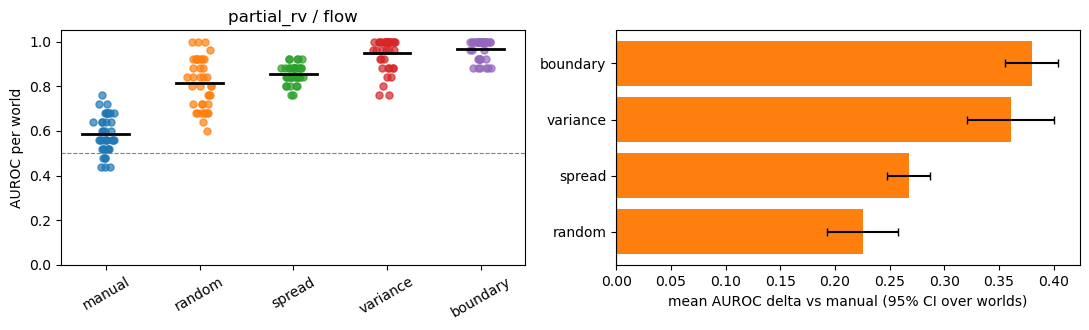

In [10]:
METHOD = "partial_rv"
g = rec[(rec.variant == "baseline") & (rec.method == METHOD)
        & (rec.kind == KINDS[0])]
order = g.groupby("strategy")["auroc"].mean().sort_values().index.tolist()
rng = np.random.default_rng(SEED)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for i, s in enumerate(order):
    v = g.loc[g.strategy == s, "auroc"].to_numpy()
    ax[0].scatter(np.full(len(v), i) + rng.normal(0, .06, len(v)), v,
                  alpha=.7, s=26)
    ax[0].plot([i - .25, i + .25], [v.mean()] * 2, c="k", lw=2)
ax[0].set_xticks(range(len(order))); ax[0].set_xticklabels(order, rotation=30)
ax[0].axhline(0.5, ls="--", c="grey", lw=.8); ax[0].set_ylim(0, 1.05)
ax[0].set_ylabel("AUROC per world"); ax[0].set_title(f"{METHOD} / {KINDS[0]}")

pv = paired[(paired.method == METHOD) & (paired.kind == KINDS[0])] \
    .set_index("strategy").reindex([o for o in order if o != "manual"])
ax[1].barh(pv.index, pv["mean_delta"],
           xerr=[pv["mean_delta"] - pv["ci_lo"], pv["ci_hi"] - pv["mean_delta"]],
           capsize=3, color="tab:orange")
ax[1].axvline(0, c="k", lw=.8)
ax[1].set_xlabel("mean AUROC delta vs manual (95% CI over worlds)")
fig.tight_layout(); plt.show()

## One-world deep dive — estimator stability and null calibration

Kept from the single-world notebook: the 84-step vs full-horizon comparison and
the shifted-series null. Run on the first baseline world.

In [11]:
w = index[index.usable & (index.variant == "baseline")].iloc[0]
art = P.load_world(w["dir"])
_, _, pls = P.run_world(art, kinds=KINDS, methods=METHODS, n_sur=5, seed=SEED)
ss = P.build_series(art["pressures"], art["flows"], pls["variance"])
ss = ss[ss["kind"].isin(KINDS)]
mats, sigs = P.district_data(ss, art["steps_day"])
ds = sorted(art["districts"]["districts"])
T = len(art["pressures"])

print(w["tag"])
display(P.sc_sample_size(mats, sigs, [84, 336, 2016, 8640, T],
                         (ds[0], ds[1]), KINDS[0], n_sur=N_SUR, seed=SEED))
display(P.sc_null_calibration(mats, KINDS[0], n_sur=N_SUR, seed=SEED))

Clc__LR_LI_LI_LC_LR__baseline


p_value        pearson              rv        
half    first second   first  second   first  second
n                                                   
84       0.02   0.02  0.9681  0.9218  0.9687  0.8501
336      0.02   0.02  0.8612  0.8251  0.8243  0.4738
2016     0.02   0.02  0.8510  0.8419  0.6789  0.6224
8640     0.02   0.02  0.8321  0.8322  0.6351  0.6710
21600    0.02   0.02  0.8289  0.8289  0.6504  0.6504

,check,value,p_value,passed
0,observed_rv,0.650394,0.02,True
1,shifted_rv,0.001547,0.18,True


## Reading this

Decision rules, set before looking:

- **A strategy is real** if its paired `ci_lo` > 0 *and* it wins in most worlds.
  A high mean with a CI straddling zero is one lucky world.
- **Prefer `variance` over `boundary`** when both clear the bar. `boundary`
  optimizes proximity to the exact pipes the label is derived from; `variance`
  uses only each client's own residual spread, so it is both non-circular and
  deployable without a shared network model.
- **If `variance_share` puts most spread on `world`**, the placement effect is
  smaller than the physics variation between worlds, and the honest conclusion
  is that placement is not the binding constraint on Graeme.
- **If the pressure `discriminative_gap` stays near zero across worlds**, drop
  pressure from the template, spend all five channels on flow, and revisit
  `dependence_oracle.topology_features`, which measures hydraulic distance
  between pressure sensor nodes.

Still out of scope: NSGA-II, MCDM weighting, leak simulation, sensor-budget
sweep (`TEMPLATE` is fixed at 2 + 3), and a non-topological adjacency label —
which is what a clean `boundary` result would need.